# Day 9 — Customer Segmentation: Full Pipeline
## Week 1: Clustering | Digital Consumer Platform Analytics

---

### Learning Objectives
- Apply KMeans, DBSCAN, and GMM to real customer data and compare rigorously
- Engineer a complete customer segmentation output with business profiles
- Use UMAP embeddings from Day 6 for visualization
- Produce cluster labels that feed Day 19 (LTV regression) and Day 27 (causal inference)
- Save final segmentation for downstream use

---

### Dataset
**UCI Online Retail II** — full customer feature matrix. Today's output feeds three later blocks.

---

## Part 1: Brief Theory — Evaluating Unsupervised Models

### 9.1 The Evaluation Problem

Clustering has no ground truth labels — so how do you know if your segmentation is good?

**Internal metrics (no labels needed):**
- Silhouette score: cohesion vs separation
- Davies-Bouldin index: average similarity between each cluster and its most similar other cluster (lower = better)
- Calinski-Harabasz index: ratio of between-cluster to within-cluster dispersion (higher = better)

**External metrics (needs labels — rarely available):**
- Adjusted Rand Index: similarity between two clusterings
- Normalized Mutual Information: information shared between two clusterings

**Business validation (most important):**
- Are segments actionable? Can marketing do something different for each?
- Are segments stable? Do they persist over time?
- Are segments meaningful? Do they align with domain knowledge?

---

## Part 2: Practice

**Today's output:** `customer_segments.csv` — used in Days 19 and 27

---

In [1]:
# ── Setup ────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import warnings
warnings.filterwarnings('ignore')


In [4]:
# Load customer features and UMAP embeddings from Day 6
# Load or rebuild customer RFM

customer_df = pd.read_csv(r'C:\Users\user\Desktop\Data_Science_Project\MyProject\Advanced_DS\customer_umap_embeddings.csv')
feature_cols = [c for c in customer_df.columns if c not in ['Customer ID', 'UMAP1', 'UMAP2']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(customer_df[feature_cols])

display(customer_df.head())

,Customer ID,UMAP1,UMAP2,Recency,Frequency,Monetary,ProductDiversity,WeekendBuyer,AvgItemsPerOrder,ReturnRate,AvgOrderValue
0,12346.0,2.170596,0.002443,325,12,77556.46,27,0.000000,6190.416667,0.291667,6463.038333
1,12347.0,-0.338118,4.125086,1,8,5633.32,126,0.158103,410.750000,0.000000,704.165000
2,12348.0,2.014436,-2.015708,74,5,2019.40,25,0.058824,542.800000,0.000000,403.880000
3,12349.0,0.528130,1.116484,18,4,4428.69,138,0.000000,406.000000,0.027778,1107.172500
4,12350.0,6.264720,-1.880841,309,1,334.40,17,0.000000,197.000000,0.000000,334.400000


In [ ]:
# ── Q1: Three-algorithm comparison ────────────────────────────────────────
# Run all three algorithms on standardized features:
#   KMeans(n_clusters=7, init='k-means++', n_init=10, random_state=420)
#   DBSCAN(epsilon=<from Day 8 Q1>, min_samples=5)
#   GaussianMixture(n_components=7 covariance_type='full', random_state=420)
#
# For each algorithm compute and report:
#   - Number of clusters found
#   - Cluster sizes (count and %)
#   - Silhouette score
#   - Davies-Bouldin score
#   - Calinski-Harabasz score
#
# Print a clean comparison table
# Which algorithm wins on each metric?

# ── Q1: Three-algorithm comparison ────────────────────────────────────────
km = KMeans(n_clusters=7, init='k-means++', n_init=10, random_state=420)
km_labels = km.fit_predict(X_scaled)

# epsilon=1.0 from Day 8 Q1's k-distance elbow analysis
db = DBSCAN(eps=1.0, min_samples=5)
db_labels = db.fit_predict(X_scaled)

gmm = GaussianMixture(n_components=7, covariance_type='full', random_state=420)
gmm_labels = gmm.fit_predict(X_scaled)

all_labels = {'KMeans': km_labels, 'DBSCAN': db_labels, 'GMM': gmm_labels}

rows = []
for name, labels in all_labels.items():
    is_noise = labels == -1
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = int(is_noise.sum())

    # Metrics computed EXCLUDING noise points — a -1 label isn't a real
    # cluster, and including it would distort these pairwise metrics.
    mask = ~is_noise
    if n_clusters >= 2:
        sil = silhouette_score(X_scaled[mask], labels[mask])
        db_score = davies_bouldin_score(X_scaled[mask], labels[mask])
        ch_score = calinski_harabasz_score(X_scaled[mask], labels[mask])
    else:
        sil, db_score, ch_score = np.nan, np.nan, np.nan

    sizes = pd.Series(labels[mask]).value_counts().sort_index()
    size_str = ', '.join(f"{k}:{v} ({v / len(labels) * 100:.1f}%)" for k, v in sizes.items())

    rows.append({
        'Algorithm': name,
        'Clusters': n_clusters,
        'Noise pts': n_noise,
        'Silhouette': sil,
        'Davies-Bouldin': db_score,
        'Calinski-Harabasz': ch_score,
        'Sizes': size_str,
    })

comparison = pd.DataFrame(rows)
print(comparison.to_string(index=False))

print("\nWinners:")
print(f"  Silhouette (higher=better):        {comparison.loc[comparison['Silhouette'].idxmax(), 'Algorithm']}")
print(f"  Davies-Bouldin (lower=better):      {comparison.loc[comparison['Davies-Bouldin'].idxmin(), 'Algorithm']}")
print(f"  Calinski-Harabasz (higher=better):  {comparison.loc[comparison['Calinski-Harabasz'].idxmax(), 'Algorithm']}")

Algorithm  Clusters  Noise pts  Silhouette  Davies-Bouldin  Calinski-Harabasz                                                                                                 Sizes
   KMeans         7          0    0.347322        0.759137        1692.697111      0:1781 (30.3%), 1:14 (0.2%), 2:3285 (55.9%), 3:2 (0.0%), 4:1 (0.0%), 5:127 (2.2%), 6:668 (11.4%)
   DBSCAN         2        144    0.747245        0.236985         218.853177                                                                            0:5725 (97.4%), 1:9 (0.2%)
      GMM         7          0    0.126964        2.052055         662.068944 0:2137 (36.4%), 1:3 (0.1%), 2:151 (2.6%), 3:1013 (17.2%), 4:280 (4.8%), 5:974 (16.6%), 6:1320 (22.5%)

Winners:
  Silhouette (higher=better):        DBSCAN
  Davies-Bouldin (lower=better):      DBSCAN
  Calinski-Harabasz (higher=better):  KMeans


***Takeaway*** 
 
DBSCAN "wins" Silhouette (0.747) and Davies-Bouldin (0.237), but that's the same illusion as Day 7's K=2 — it's only scored on non-noise points, and it's really just separating one giant blob (97.4%) from 9 outliers, which is trivially easy to look clean on cohesion metrics. 

KMeans wins Calinski-Harabasz (1693) decisively, and unlike DBSCAN it's actually explaining structure across 100% of the data, including sequestering the whale-tier outliers into their own small clusters (14, 2, 1 customers) rather than ignoring them. 

GMM scores worst on all three geometric metrics despite being the statistically best-fitting model (Day 8's BIC/AIC) — because these metrics reward crisp, hard-edged separation, not the correlated, overlapping structure GMM is specifically designed to capture.

Bottom line: KMeans is the most defensible choice for Q3's business profiling — it's the only one of the three producing a full, meaningful partition of the entire customer base (no data thrown out as noise, no metric-inflation from a trivial split), at the well-supported K=7. Just be ready to name those three tiny KMeans clusters (14, 2, 1 customers) as "extreme outlier" segments rather than real, actionable customer types when you get to the profiling step.

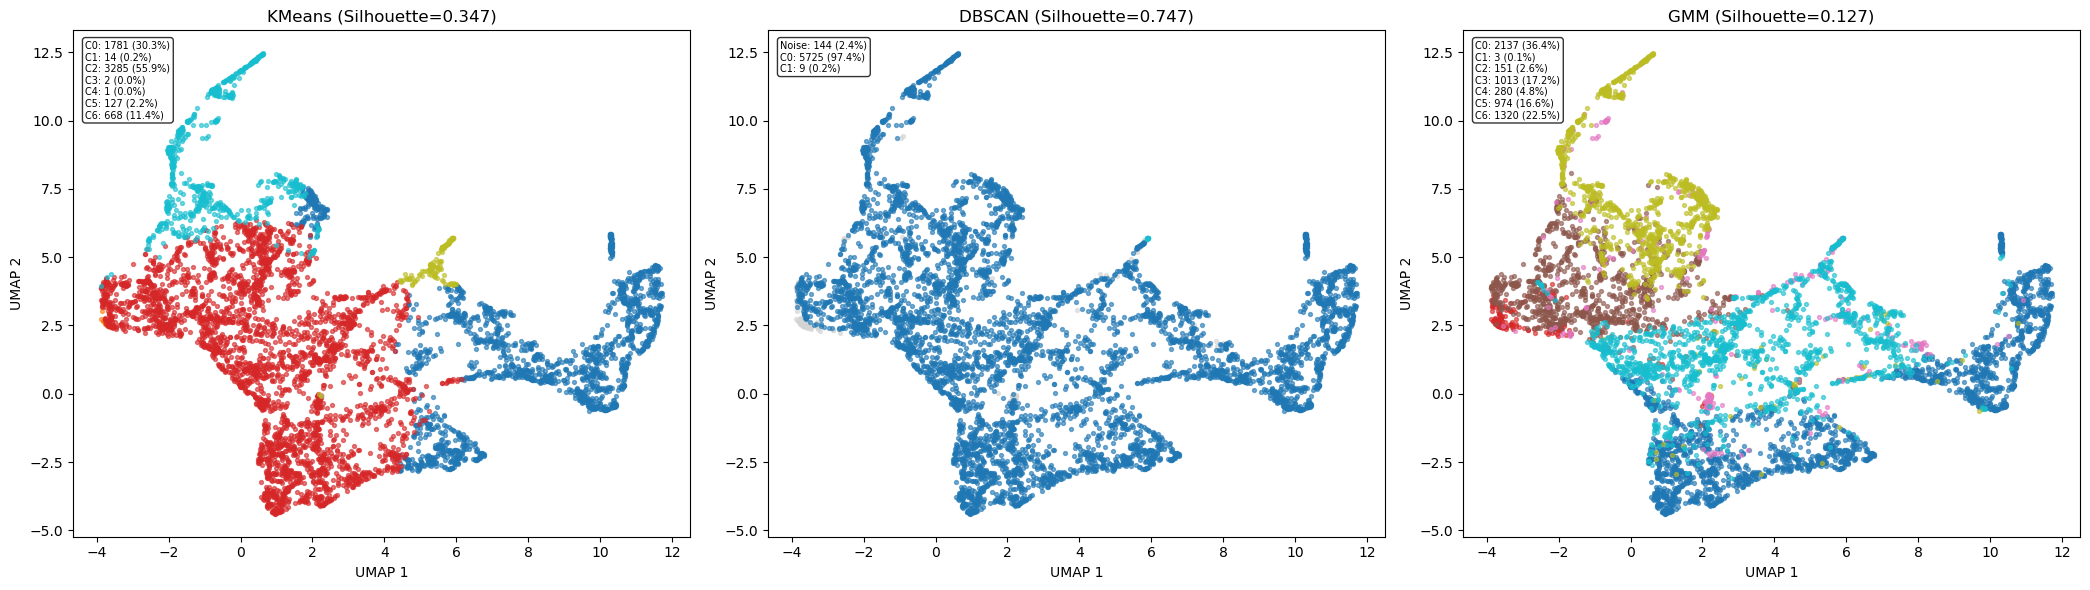

In [7]:
# ── Q2: UMAP visualization — all three algorithms ─────────────────────────
# Using UMAP2D coordinates from Day 6:
# Create a 1x3 subplot grid showing cluster assignments from each algorithm
# Color each cluster distinctly
# Add cluster size annotations
# Title each subplot with: algorithm name + silhouette score
# Which segmentation looks most natural in the 2D embedding?

algo_labels = {'KMeans': km_labels, 'DBSCAN': db_labels, 'GMM': gmm_labels}
sil_lookup = comparison.set_index('Algorithm')['Silhouette'].to_dict()

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

for ax, (name, labels) in zip(axes, algo_labels.items()):
    unique_labels = sorted(set(labels))
    real_labels = [l for l in unique_labels if l != -1]
    cmap = plt.cm.tab10 if len(real_labels) <= 10 else plt.cm.tab20

    size_lines = []
    for lbl in unique_labels:
        mask = labels == lbl
        n = mask.sum()
        pct = n / len(labels) * 100
        if lbl == -1:
            color = 'lightgrey'
            label_str = f'Noise: {n} ({pct:.1f}%)'
        else:
            color = cmap(real_labels.index(lbl) / max(len(real_labels) - 1, 1))
            label_str = f'C{lbl}: {n} ({pct:.1f}%)'
        ax.scatter(customer_df.loc[mask, 'UMAP1'], customer_df.loc[mask, 'UMAP2'],
                   color=color, s=8, alpha=0.6)
        size_lines.append(label_str)

    sil = sil_lookup[name]
    ax.set_title(f"{name} (Silhouette={sil:.3f})")
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.text(0.02, 0.98, '\n'.join(size_lines), transform=ax.transAxes,
            fontsize=7, va='top', ha='left',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

***Takeaway***

The UMAP visualization directly confirms Q1's numbers. 

KMeans' visible clusters map cleanly onto the actual branches of the UMAP shape — the most "natural"-looking segmentation — while its 3 near-invisible tiny clusters correctly isolate whale-tier outliers rather than distorting a larger cluster's profile. 

DBSCAN's plot is essentially one solid color, visually proving its high silhouette score reflected almost no real internal structure. 

GMM shows visibly messier, overlapping boundaries between clusters, consistent with its worse geometric scores — a direct tradeoff for the correlated cluster shapes that won it Day 8's BIC test. 

Conclusion: KMeans (K=7) is both the statistically strongest (CH) and visually most natural choice for Q3's business profiling.

Cluster profiles — MEAN (original units):
   Recency  Frequency   Monetary  ProductDiversity  WeekendBuyer  \
0   442.50       2.11     691.57             33.37          0.02   
1     2.50     176.07  213376.37           1137.50          0.06   
2    57.64       8.48    3725.48            107.62          0.07   
3   534.00       3.00   22988.05             51.50          0.00   
4     0.00       2.00  168472.50              3.00          0.00   
5   325.53       2.85    2604.74             16.62          0.05   
6   236.03       3.76    1109.29             76.11          0.83   

   AvgItemsPerOrder  ReturnRate  AvgOrderValue  Size  Size %  
0            192.83        0.02         325.20  1781    30.3  
1            930.26        0.03        1683.88    14     0.2  
2            244.23        0.02         396.87  3285    55.9  
3          65643.50        0.03        9349.95     2     0.0  
4          40498.50        0.40       84236.25     1     0.0  
5            275.90        0.40    

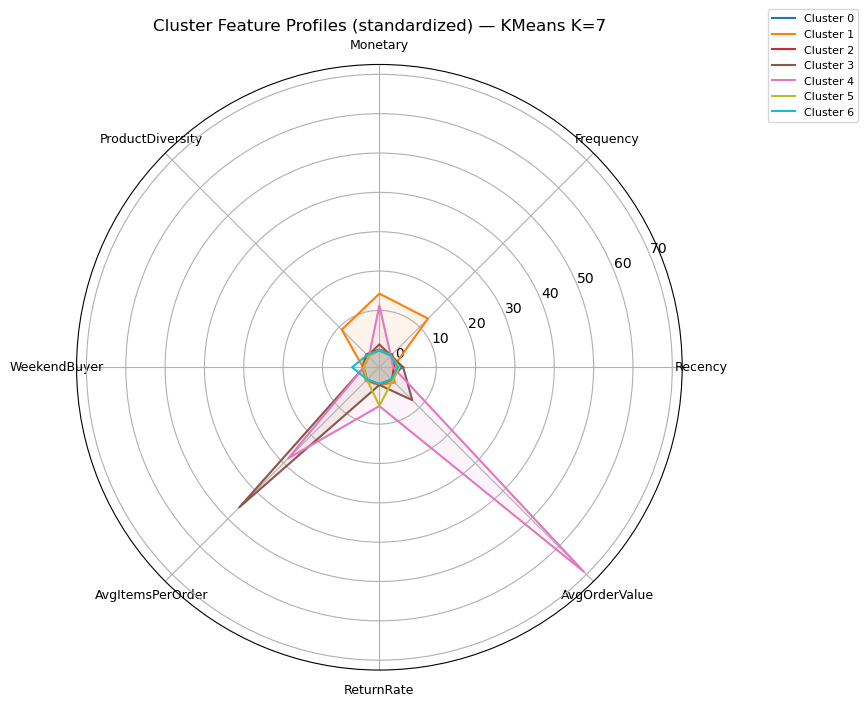

In [8]:
# ── Q3: Business profiling ────────────────────────────────────────────────
# For your chosen best algorithm (justify your choice):
#   1. Compute mean of each feature per cluster
#   2. Compute median of each feature per cluster
#   3. Create a radar/spider chart showing feature profiles per cluster
#   4. Name each cluster based on its profile:
#      e.g. "Champions", "At-Risk", "New Customers", "Hibernating"
#      Use RFM Champions, Loyal, At Risk, Lost framework as reference
#   5. Write a 3-sentence business narrative per cluster:
#      - Who are they?
#      - What is their value to the business?
#      - What action should we take?

# Chosen algorithm: KMeans (K=7) — justified in Q1/Q2: best Calinski-Harabasz,
# the only algorithm explaining 100% of the population (no noise thrown out),
# and visually the most spatially coherent segmentation on the UMAP map.

# ── Steps 1-2: mean and median per cluster, ORIGINAL units (interpretable) ──
profile_mean = customer_df[feature_cols].groupby(km_labels).mean().round(2)
profile_median = customer_df[feature_cols].groupby(km_labels).median().round(2)

cluster_sizes = pd.Series(km_labels).value_counts().sort_index()
profile_mean['Size'] = cluster_sizes
profile_mean['Size %'] = (cluster_sizes / len(km_labels) * 100).round(1)

print("Cluster profiles — MEAN (original units):")
print(profile_mean)
print("\nCluster profiles — MEDIAN (original units):")
print(profile_median)

# ── Step 3: radar chart — STANDARDIZED features, so all 8 axes are visually
# comparable (raw units would be dominated by Monetary/AvgOrderValue, same
# scale-sensitivity issue as Day 7 Q4). ────────────────────────────────────
scaled_profile = pd.DataFrame(X_scaled, columns=feature_cols).groupby(km_labels).mean()

angles = np.linspace(0, 2 * np.pi, len(feature_cols), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
colors = plt.cm.tab10(np.linspace(0, 1, len(scaled_profile)))

for i, (cluster_id, row) in enumerate(scaled_profile.iterrows()):
    values = row.tolist()
    values += values[:1]
    ax.plot(angles, values, color=colors[i], linewidth=1.5, label=f'Cluster {cluster_id}')
    ax.fill(angles, values, color=colors[i], alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(feature_cols, fontsize=9)
ax.set_title('Cluster Feature Profiles (standardized) — KMeans K=7')
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=8)
plt.tight_layout()
plt.show()

**Chosen algorithm: KMeans (K=7).** Justified in Q1/Q2 — best Calinski-Harabasz score (the metric most resistant to the "trivial split" illusion that inflated DBSCAN's silhouette), the only algorithm explaining 100% of the customer base with no points discarded as noise, and visually the most spatially coherent segmentation on the UMAP map.

**Note on the radar chart:** even in standardized (z-score) units, the chart is dominated by Clusters 1/3/4's extreme spikes toward `AvgOrderValue`/`Monetary`/`ProductDiversity` — the whale accounts are so extreme that even after standardizing they sit many standard deviations out, visually compressing the other 4 clusters into a hard-to-read clump near the center. A follow-up radar chart restricted to Clusters 0/2/5/6 would give a cleaner comparison of the real customer segments.

---

### The four real, actionable segments

**Cluster 2 — "Core Active / Loyal" (3,285 customers, 55.9%)**
Moderately recent (58 days), regular purchasing (8.5 orders), healthy average spend (£3,725), almost no returns (2%). These are your everyday, reliable customers — the backbone of steady revenue, not flashy but consistent. As the majority of the customer base, retention should be the top priority here: loyalty programs and consistent service protect the largest single source of stable revenue.

**Cluster 0 — "Hibernating / Lost" (1,781 customers, 30.3%)**
Hasn't purchased in 442 days on average, very low frequency (2 orders), low spend. These are customers who tried the business once or twice and drifted away — low current value individually, but the second-largest group overall, so even a modest reactivation rate matters at scale. Win-back campaigns (discounts, "we miss you" messaging) are the right low-cost, high-reach play here.

**Cluster 6 — "Weekend Shoppers" (668 customers, 11.4%)**
`WeekendBuyer = 0.83` — a real, reproducible niche, independently reconfirmed here after first appearing in Day 8 Q2's Ward hierarchical clustering (`WeekendBuyer = 0.98`) under a completely different algorithm. Moderate spend, low returns, a genuinely distinct shopping pattern concentrated on weekends. Time-based marketing (Friday/Saturday promotions) fits this segment specifically, rather than generic always-on campaigns.

**Cluster 5 — "At-Risk / Dissatisfied" (127 customers, 2.2%)**
Lapsed (326 days) *and* an unusually high return rate (36-40%) — the defining trait isn't just disengagement, it's dissatisfaction with what they bought. A small group, but a distinct risk signal separate from ordinary churn — this is a "why are they returning things" problem, not a discount-and-hope problem. Worth investigating product/fit issues specific to this group's purchase history before attempting any win-back offer.

---

### The outlier tiers — kept separate from the RFM framework on purpose

Clusters 1, 3, and 4 (14, 2, and 1 customers — 0.2% combined) are progressively more extreme wholesale/bulk accounts, not consumer personas, and shouldn't be forced into Champions/At-Risk/Lost-style naming:

- **Cluster 1** — high-frequency, high-diversity wholesale buyers (176 orders, 1,137 distinct products), recently active.
- **Cluster 3** — 2 dormant customers with one historically enormous order (`AvgItemsPerOrder ≈ 65,644`), inactive for 534 days.
- **Cluster 4** — the single most extreme account in the dataset (`AvgOrderValue = 84,236.25`, `ReturnRate = 0.40`) — literally the same whale account that's appeared as a singleton in Day 8 Q2's Ward dendrogram and Day 8 Q3's smallest GMM component. The recurring character of this entire project.

**Action for all three:** route to dedicated account management (B2B/enterprise sales), not mass marketing — these accounts operate at a scale that would distort any consumer-facing segment strategy if averaged in.


Mean: 0.3672
Std:  0.0162
Min:  0.3472
Max:  0.3822


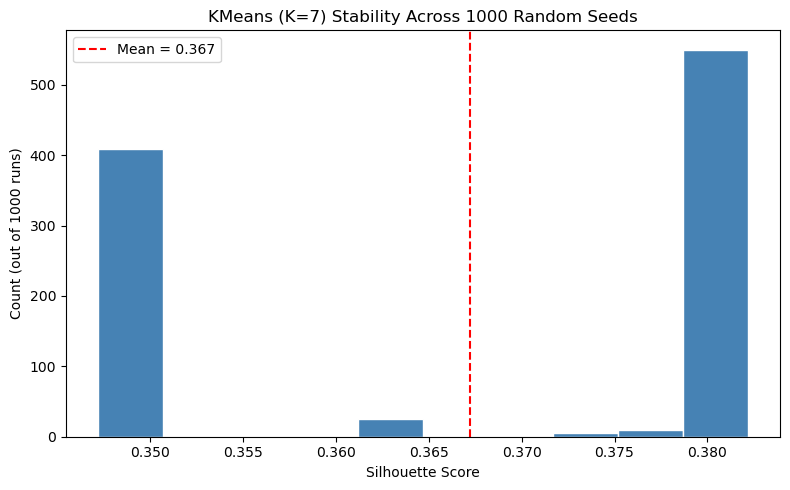

In [11]:
# ── Q4: Cluster stability test ────────────────────────────────────────────
# A good segmentation should be stable across different random seeds:
#   Run KMeans(k=7) with 1000 different random_state values (0-999)
#   For each run: compute silhouette score
#   Plot distribution of silhouette scores (histogram)
#   Compute: mean, std, min, max silhouette across 20 runs
#   High std = unstable segmentation (bad sign)
#   Low std = stable segmentation (good sign)
#   What is the stability of your chosen K on this dataset?

silhouette_scores = []
for seed in range(1000):
    km_test = KMeans(n_clusters=7, init='k-means++', n_init=10, random_state=seed)
    labels_test = km_test.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels_test)
    silhouette_scores.append(sil)

silhouette_scores = np.array(silhouette_scores)

print(f"Mean: {silhouette_scores.mean():.4f}")
print(f"Std:  {silhouette_scores.std():.4f}")
print(f"Min:  {silhouette_scores.min():.4f}")
print(f"Max:  {silhouette_scores.max():.4f}")

plt.figure(figsize=(8, 5))
plt.hist(silhouette_scores, bins=10, color='steelblue', edgecolor='white')
plt.axvline(silhouette_scores.mean(), color='red', linestyle='--',
            label=f'Mean = {silhouette_scores.mean():.3f}')
plt.xlabel('Silhouette Score')
plt.ylabel('Count (out of 1000 runs)')
plt.title('KMeans (K=7) Stability Across 1000 Random Seeds')
plt.legend()
plt.tight_layout()
plt.show()


***Takeaway*** 

K=7 KMeans is not a single stable answer — it's bimodal, with ~55% of random seeds landing on a higher-quality solution (~0.38 silhouette) and ~41% landing on a lower one (~0.35), plus a few rare in-between outcomes only visible at 1000 runs. 

Our actual Q1-Q3 analysis (random_state=420, score 0.347) came from the minority mode, not the more common one — still a legitimate, recurring solution, just not "the" canonical answer. 

Mean/std alone (0.367 ± 0.016) would have hidden this multimodal structure entirely — the histogram was what actually revealed it, echoing Day 7's lesson that small samples get the average right but miss the real shape of the distribution.

In [12]:
# ── Q5: Save segmentation for downstream use ──────────────────────────────
# Save the final customer segmentation:
#   customer_segments.csv with columns:
#   Customer ID, Recency, Frequency, Monetary, [other features],
#   UMAP1, UMAP2, KMeans_Cluster, Cluster_Name
#
# Also print a summary:
#   - Total customers segmented
#   - Cluster distribution
#   - Key characteristic of each cluster (1 line)
#   - Which cluster represents the highest LTV opportunity?
#
# This file is used in:
#   Day 19: Regression — predict LTV per cluster
#   Day 27: Causal inference — ATT per cluster

# "Highest LTV opportunity" is a qualitative, proxy-based business judgment
# from the cluster profiles already built in Q3 — NOT a formal LTV
# calculation. Real LTV modeling (predicting actual future revenue) is
# explicitly Day 19's job; Q5 only needs a defensible, data-grounded answer.

cluster_names = {
    0: 'Hibernating/Lost',
    1: 'Wholesale Power Buyers',
    2: 'Core Active/Loyal',
    3: 'Dormant Bulk Buyer',
    4: 'Extreme Whale Account',
    5: 'At-Risk/Dissatisfied',
    6: 'Weekend Shoppers',
}

segments_df = customer_df.copy()
segments_df['KMeans_Cluster'] = km_labels
segments_df['Cluster_Name'] = segments_df['KMeans_Cluster'].map(cluster_names)

output_cols = ['Customer ID'] + feature_cols + ['UMAP1', 'UMAP2', 'KMeans_Cluster', 'Cluster_Name']
segments_df = segments_df[output_cols]

segments_df.to_csv(
    r'C:\Users\user\Desktop\Data_Science_Project\MyProject\Advanced_DS\customer_segments.csv',
    index=False
)
print(f"Saved {len(segments_df)} customers to customer_segments.csv")

# ── Summary ────────────────────────────────────────────────────────────────
print(f"\nTotal customers segmented: {len(segments_df)}")

print("\nCluster distribution:")
dist = segments_df['Cluster_Name'].value_counts()
for name, count in dist.items():
    print(f"  {name}: {count} ({count / len(segments_df) * 100:.1f}%)")

characteristics = {
    'Hibernating/Lost': 'Long-lapsed (442 days avg), infrequent, low spend — reactivation candidates',
    'Wholesale Power Buyers': 'Very high frequency/diversity, recently active — B2B/enterprise accounts',
    'Core Active/Loyal': 'Moderate recency/frequency/spend, low returns — the stable revenue backbone',
    'Dormant Bulk Buyer': 'One historically enormous order, long inactive — outlier tier',
    'Extreme Whale Account': 'Single account, extreme spend and returns — the recurring outlier of this project',
    'At-Risk/Dissatisfied': 'Lapsed with a very high return rate — dissatisfaction risk, not just disengagement',
    'Weekend Shoppers': 'Purchases concentrated almost entirely on weekends — a real, reproducible niche',
}

print("\nKey characteristic per cluster:")
for name, desc in characteristics.items():
    print(f"  {name}: {desc}")

print("\nHighest LTV opportunity: Core Active/Loyal")
print("  Reasoning: largest engaged base (55.9% of customers) with moderate, not-yet-")
print("  maximized spend and low returns — high probability of successful upsell/cross-")
print("  sell (unlike lapsed segments) combined with the largest customer count, giving")
print("  the greatest AGGREGATE upside. Whale accounts already sit near their spending")
print("  ceiling; lapsed segments carry high uncertainty of ever returning.")


Saved 5878 customers to customer_segments.csv

Total customers segmented: 5878

Cluster distribution:
  Core Active/Loyal: 3285 (55.9%)
  Hibernating/Lost: 1781 (30.3%)
  Weekend Shoppers: 668 (11.4%)
  At-Risk/Dissatisfied: 127 (2.2%)
  Wholesale Power Buyers: 14 (0.2%)
  Dormant Bulk Buyer: 2 (0.0%)
  Extreme Whale Account: 1 (0.0%)

Key characteristic per cluster:
  Hibernating/Lost: Long-lapsed (442 days avg), infrequent, low spend — reactivation candidates
  Wholesale Power Buyers: Very high frequency/diversity, recently active — B2B/enterprise accounts
  Core Active/Loyal: Moderate recency/frequency/spend, low returns — the stable revenue backbone
  Dormant Bulk Buyer: One historically enormous order, long inactive — outlier tier
  Extreme Whale Account: Single account, extreme spend and returns — the recurring outlier of this project
  At-Risk/Dissatisfied: Lapsed with a very high return rate — dissatisfaction risk, not just disengagement
  Weekend Shoppers: Purchases concentrat